In [1]:
# Exploratory Data Analysis - 보험 청구 사기 탐지
# 2025 NESS Statathon

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# 데이터 로드
DATA_DIR = Path('.')
train = pd.read_csv(DATA_DIR / 'train_2025.csv')
test = pd.read_csv(DATA_DIR / 'test_2025.csv')

In [6]:
# 1. 데이터셋 구조 분석
print("=" * 60)
print("1. 데이터셋 구조")
print("=" * 60)
print(f"\n[Train] shape: {train.shape}")
print(f"[Test]  shape: {test.shape}")

print("\n--- 컬럼 목록 및 타입 ---")
print(train.dtypes)

print("\n--- 기본 통계 ---")
display(train.describe(include= 'all').T)

print("\n--- train.head(10) ---")
display(train.head())

1. 데이터셋 구조

[Train] shape: (18000, 25)
[Test]  shape: (12000, 24)

--- 컬럼 목록 및 타입 ---
claim_number                 int64
age_of_driver                int64
gender                      object
marital_status             float64
safty_rating                 int64
annual_income                int64
high_education_ind           int64
address_change_ind           int64
living_status               object
zip_code                     int64
claim_date                  object
claim_day_of_week           object
accident_site               object
past_num_of_claims           int64
witness_present_ind        float64
liab_prct                    int64
channel                     object
policy_report_filed_ind      int64
claim_est_payout           float64
age_of_vehicle               int64
vehicle_category            object
vehicle_price              float64
vehicle_color               object
vehicle_weight             float64
fraud                        int64
dtype: object

--- 기본 통계 ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
claim_number,18000.0,NaN,NaN,NaN,15028.406556,8682.690109,1.0,7435.75,15099.0,22539.25,29999.0
age_of_driver,18000.0,NaN,NaN,NaN,43.704722,12.010833,18.0,35.0,43.0,51.0,249.0
gender,18000,2,M,9377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,17998.0,NaN,NaN,NaN,0.711079,0.453274,0.0,0.0,1.0,1.0,1.0
safty_rating,18000.0,NaN,NaN,NaN,73.535944,15.453003,1.0,65.0,76.0,85.0,100.0
annual_income,18000.0,NaN,NaN,NaN,77282.027111,27477.128085,30015.0,53276.0,77141.5,101196.25,124993.0
high_education_ind,18000.0,NaN,NaN,NaN,0.703056,0.456925,0.0,0.0,1.0,1.0,1.0
address_change_ind,18000.0,NaN,NaN,NaN,0.574056,0.494499,0.0,0.0,1.0,1.0,1.0
living_status,18000,2,Own,9998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,18000.0,NaN,NaN,NaN,49866.894056,29170.73745,0.0,20111.0,50027.0,80038.0,85083.0



--- train.head(10) ---


,claim_number,age_of_driver,gender,marital_status,safty_rating,annual_income,high_education_ind,address_change_ind,living_status,zip_code,...,liab_prct,channel,policy_report_filed_ind,claim_est_payout,age_of_vehicle,vehicle_category,vehicle_price,vehicle_color,vehicle_weight,fraud
0,2759,58,M,1.0,83,117115,1,0,Own,85027,...,88,Broker,0,0.00,4,Medium,55066.875563,other,21515.14956,0
1,11338,37,F,0.0,76,57945,1,0,Rent,85004,...,2,Broker,1,0.00,1,Large,29937.566096,blue,22570.44842,0
2,23150,33,F,0.0,82,79027,1,0,Rent,85027,...,95,Broker,1,0.00,1,Compact,15000.000000,black,10701.08860,0
3,19040,43,F,0.0,40,98544,1,0,Own,15028,...,100,Broker,0,850.63,1,Large,92867.354408,white,21434.93439,1
4,10803,43,F,1.0,84,62619,1,1,Own,20148,...,58,Broker,0,3375.85,1,Medium,74071.734863,blue,48036.29694,0


2. 분포 분석

[Target(fraud) 분포]
fraud
0    15152
1     2848
Name: count, dtype: int64
fraud
0    0.8418
1    0.1582
Name: proportion, dtype: float64


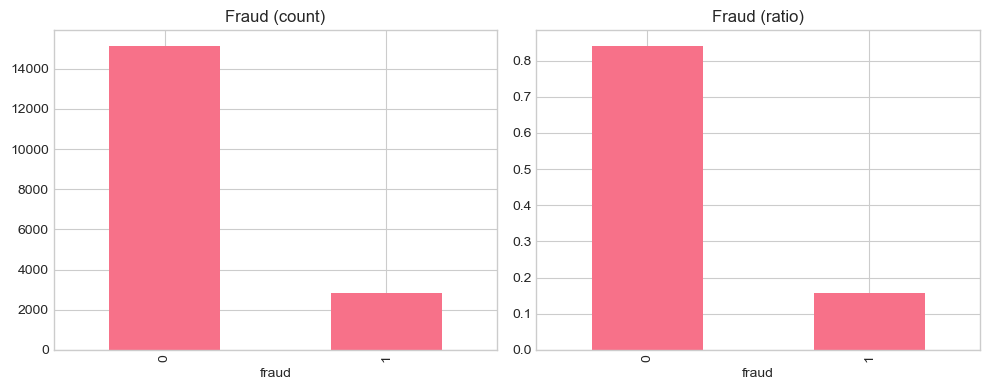

In [7]:
# 2. 분포 분석
print("=" * 60)
print("2. 분포 분석")
print("=" * 60)

# 타깃(fraud) 분포
print("\n[Target(fraud) 분포]")
print(train.fraud.value_counts())
print(train.fraud.value_counts(normalize= True).round(4))

fig, axes = plt.subplots(1, 2, figsize= (10, 4))
train.fraud.value_counts().plot(kind= 'bar', ax= axes[0], title= 'Fraud (count)')
train.fraud.value_counts(normalize= True).plot(kind= 'bar', ax= axes[1], title= 'Fraud (ratio)')
plt.tight_layout()
plt.show()


[Numerical Variable 분포]


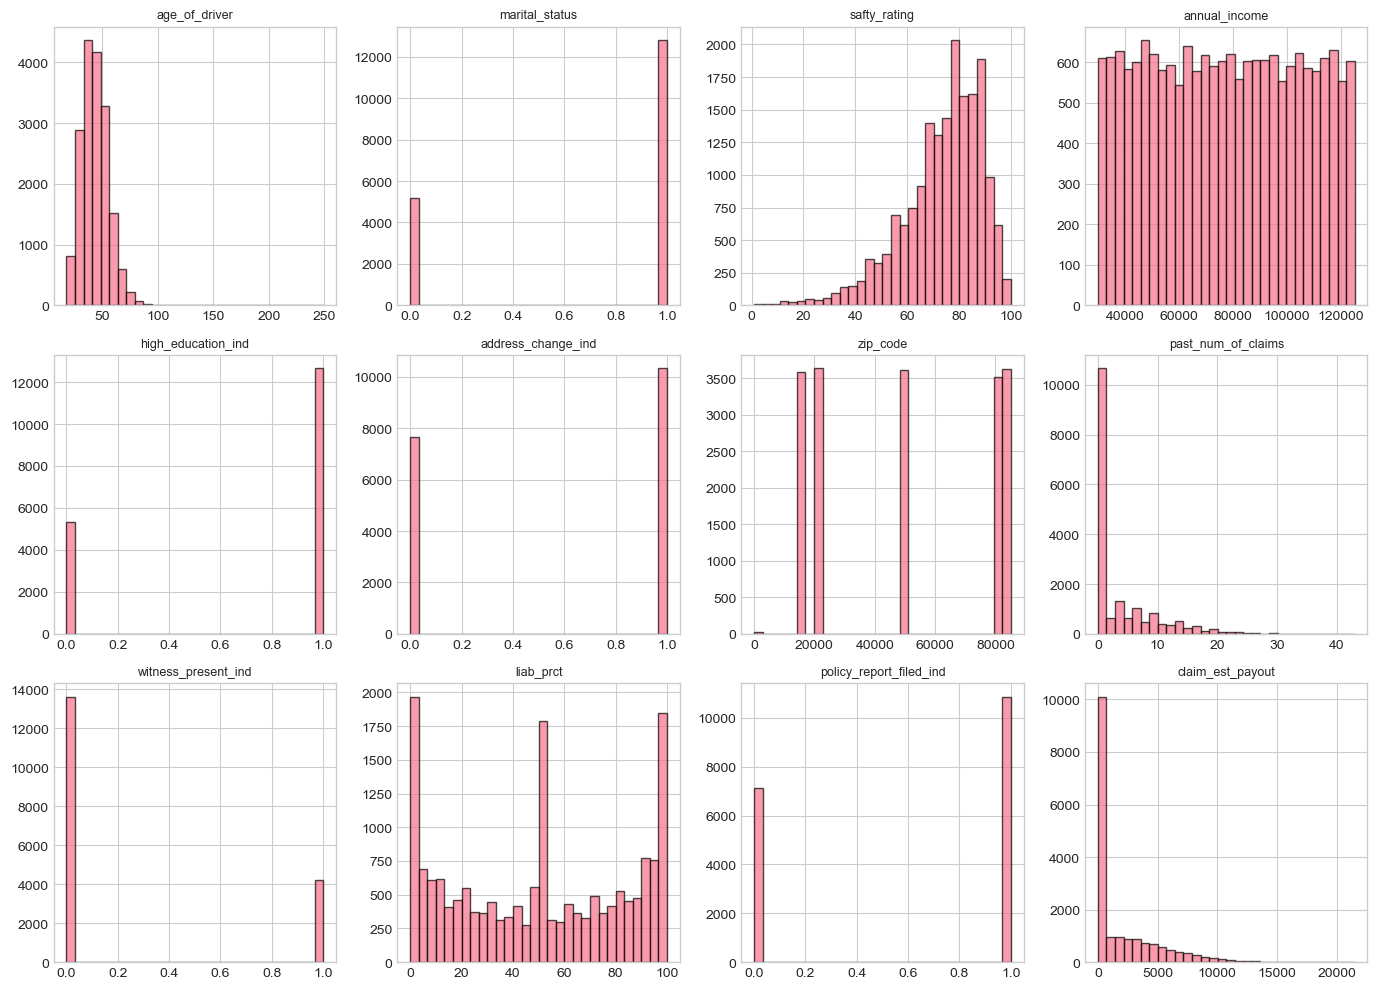

In [8]:
# 수치형 변수 히스토그램 (주요 변수만)
print("\n[Numerical Variable 분포]")
num_cols = train.select_dtypes(include= [np.number]).columns.drop(['claim_number', 'fraud'], errors= 'ignore')
n_show = min(12, len(num_cols))
fig, axes = plt.subplots(3, 4, figsize= (14, 10))
axes = axes.ravel()
for i, col in enumerate(num_cols[:n_show]):
    train[col].hist(ax= axes[i], bins= 30, edgecolor= 'black', alpha= 0.7)
    axes[i].set_title(col, fontsize= 9)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# 범주형 변수 고유값 개수 확인
print("\n--- Categorical Variable 고유값 개수 ---")
cat_cols = train.select_dtypes(include= ['object']).columns.tolist()
for c in cat_cols:
    print(f"  {c}: {train[c].nunique()} unique")


--- Categorical Variable 고유값 개수 ---
  gender: 2 unique
  living_status: 2 unique
  claim_date: 731 unique
  claim_day_of_week: 7 unique
  accident_site: 3 unique
  channel: 3 unique
  vehicle_category: 3 unique
  vehicle_color: 7 unique



[Categorical Variable 분포]


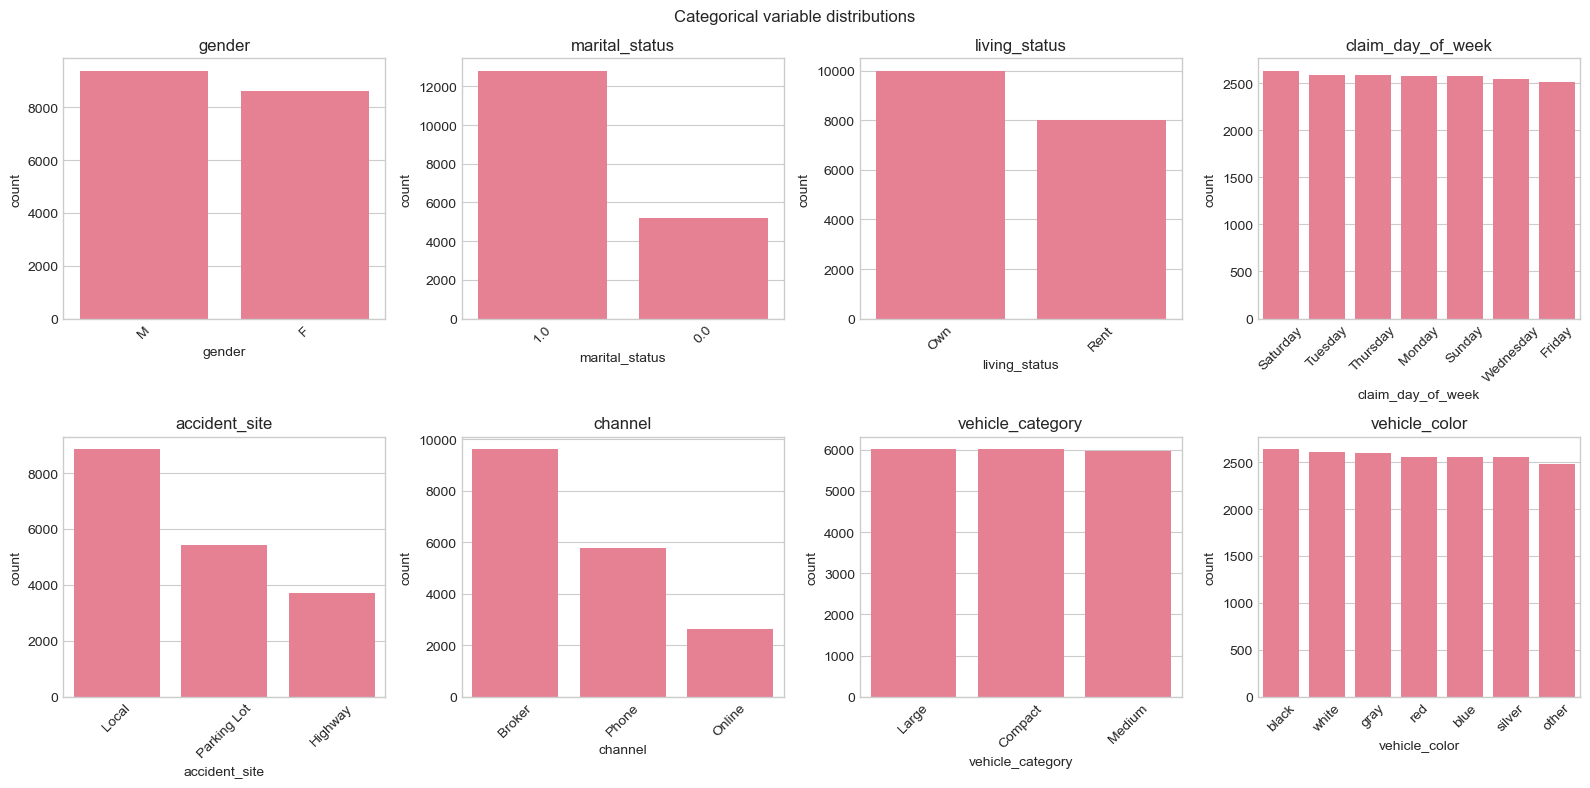

In [10]:
# 범주형 변수 분포
print("\n[Categorical Variable 분포]")
cat_cols = ['gender', 'marital_status', 'living_status', 'claim_day_of_week', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color']
cat_in_train = [c for c in cat_cols if c in train.columns]

fig, axes = plt.subplots(2, 4, figsize= (16, 8))
axes = axes.ravel()
for i, col in enumerate(cat_in_train[:8]):
    order = train[col].value_counts().index
    sns.countplot(data= train, x=col, ax= axes[i], order= order)
    axes[i].tick_params(axis= 'x', rotation=45)
    axes[i].set_title(col)
plt.suptitle('Categorical variable distributions')
plt.tight_layout()
plt.show()

3. 상관관계


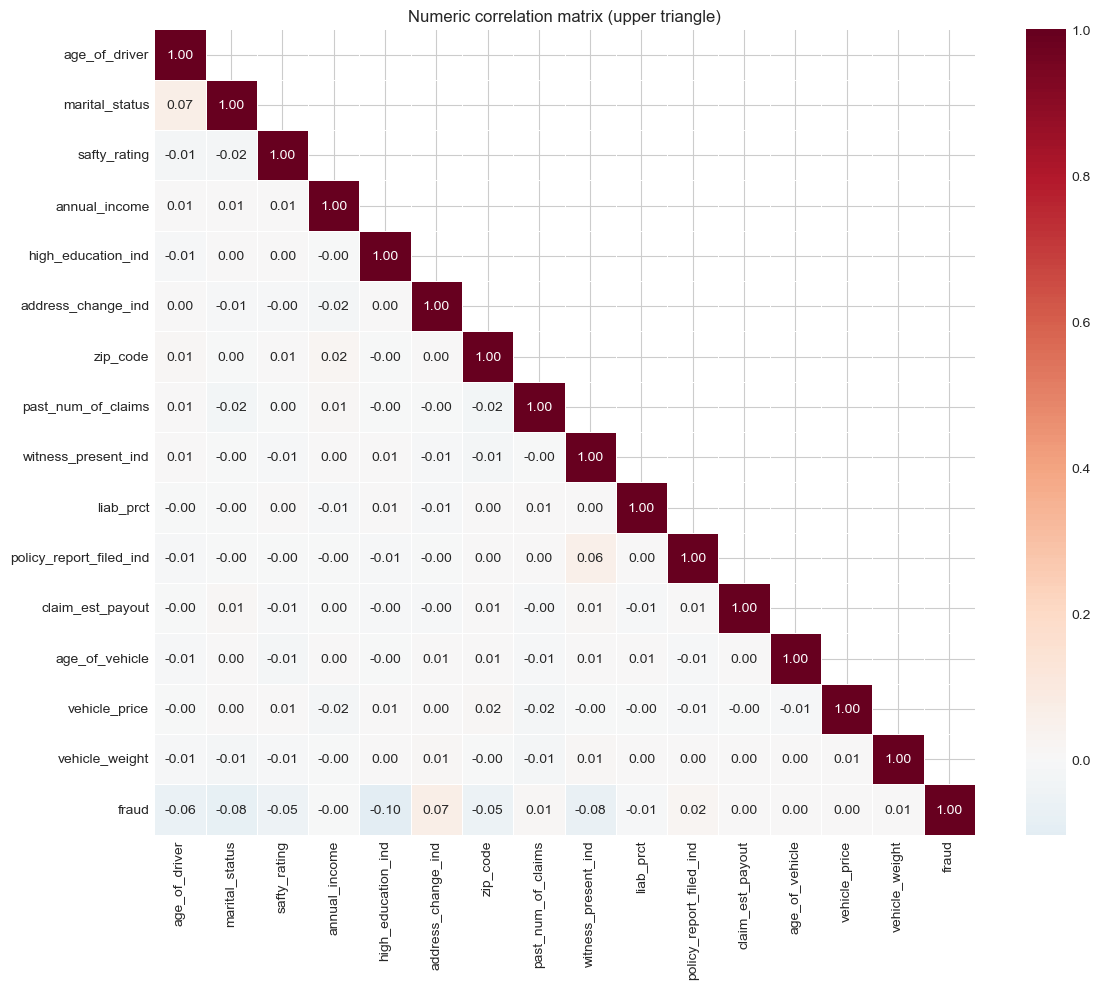


Fraud와 상관관계 (절대값 기준):
high_education_ind        -0.1030
marital_status            -0.0814
witness_present_ind       -0.0756
address_change_ind         0.0724
age_of_driver             -0.0648
zip_code                  -0.0535
safty_rating              -0.0482
policy_report_filed_ind    0.0246
past_num_of_claims         0.0110
liab_prct                 -0.0080
vehicle_weight             0.0058
vehicle_price              0.0022
annual_income             -0.0015
claim_est_payout           0.0013
age_of_vehicle             0.0009


In [11]:
# 3. 상관관계 분석
print("=" * 60)
print("3. 상관관계")
print("=" * 60)

# 수치형만 상관행렬
num_for_corr = train.select_dtypes(include= [np.number]).drop(['claim_number'], axis= 1, errors= 'ignore')
corr = num_for_corr.corr()

fig, ax = plt.subplots(figsize= (12, 10))
mask = np.triu(np.ones_like(corr, dtype= bool), k= 1)
sns.heatmap(corr, mask=mask, annot= True, fmt= '.2f', center= 0, cmap= 'RdBu_r', ax= ax, linewidths= 0.5)
plt.title('Numeric correlation matrix (upper triangle)')
plt.tight_layout()
plt.show()

# 타깃과 상관 높은 변수
if 'fraud' in corr.columns:
    target_corr = corr['fraud'].drop('fraud', errors= 'ignore').sort_values(ascending= False, key= lambda x: x.abs())
    print("\nFraud와 상관관계 (절대값 기준):")
    print(target_corr.round(4).to_string())

In [12]:
# Fraud 비율 by 범주형 변수
print("\n[Fraud 비율 by 범주형 변수]")
for col in cat_in_train[:]:
    rate = train.groupby(col)['fraud'].mean().sort_values(ascending= False)
    print(rate.round(4).to_string(), "\n")


[Fraud 비율 by 범주형 변수]
gender
F    0.1787
M    0.1394 

marital_status
0.0    0.2048
1.0    0.1392 

living_status
Rent    0.1726
Own     0.1467 

claim_day_of_week
Tuesday      0.1800
Wednesday    0.1678
Monday       0.1598
Sunday       0.1579
Friday       0.1492
Thursday     0.1484
Saturday     0.1445 

accident_site
Highway        0.2155
Local          0.1756
Parking Lot    0.0904 

channel
Broker    0.1599
Phone     0.1569
Online    0.1549 

vehicle_category
Compact    0.1640
Medium     0.1568
Large      0.1538 

vehicle_color
silver    0.1690
red       0.1622
black     0.1621
blue      0.1572
white     0.1535
gray      0.1524
other     0.1511 



4. 결측치


,Missing count,Ratio
witness_present_ind,132,0.73
marital_status,2,0.01


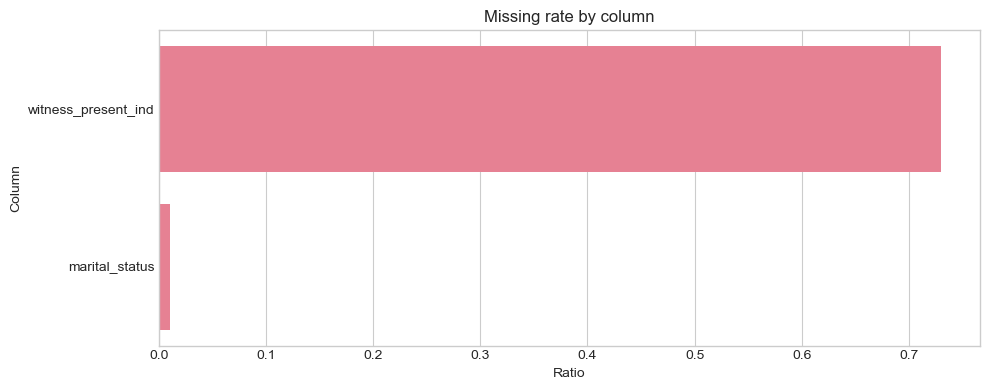

In [13]:
# 4. 결측치 및 데이터 품질 검사
print("=" * 60)
print("4. 결측치")
print("=" * 60)

missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing count': missing, 'Ratio': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0].sort_values('Missing count', ascending= False)

if len(missing_df) == 0:
    print("결측치 없음.")
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize= (10, max(4, len(missing_df) * 0.4)))
    sns.barplot(data=missing_df.reset_index(), y= 'index', x= 'Ratio', ax= ax)
    ax.set_ylabel('Column')
    plt.title('Missing rate by column')
    plt.tight_layout()
    plt.show()

**결측치 처리 계획**
- `marital_status` : 극소량이므로 결측 있는 행 삭제.
- `witness_present_ind` : '목격자 없음' 자체가 의미있는 정보일 가능성이 높으므로 0으로 대체하고 플래그 생성.

5. 이상치 탐지


,Q1,Q3,Lower,Upper,Outlier Count,Outlier (%)
witness_present_ind,0.0,0.00,0.00,0.00,4237.0,23.54
age_of_vehicle,1.0,4.00,-3.50,8.50,1727.0,9.59
past_num_of_claims,0.0,6.00,-9.00,15.00,916.0,5.09
claim_est_payout,0.0,3363.14,-5044.71,8407.86,837.0,4.65
vehicle_price,15000.0,42339.72,-26009.58,83349.31,469.0,2.61
vehicle_weight,13978.0,29366.56,-9104.85,52449.40,440.0,2.44
safty_rating,65.0,85.00,35.00,115.00,407.0,2.26
age_of_driver,35.0,51.00,11.00,75.00,190.0,1.06
marital_status,0.0,1.00,-1.50,2.50,0.0,0.00
annual_income,53276.0,101196.25,-18604.38,173076.62,0.0,0.00


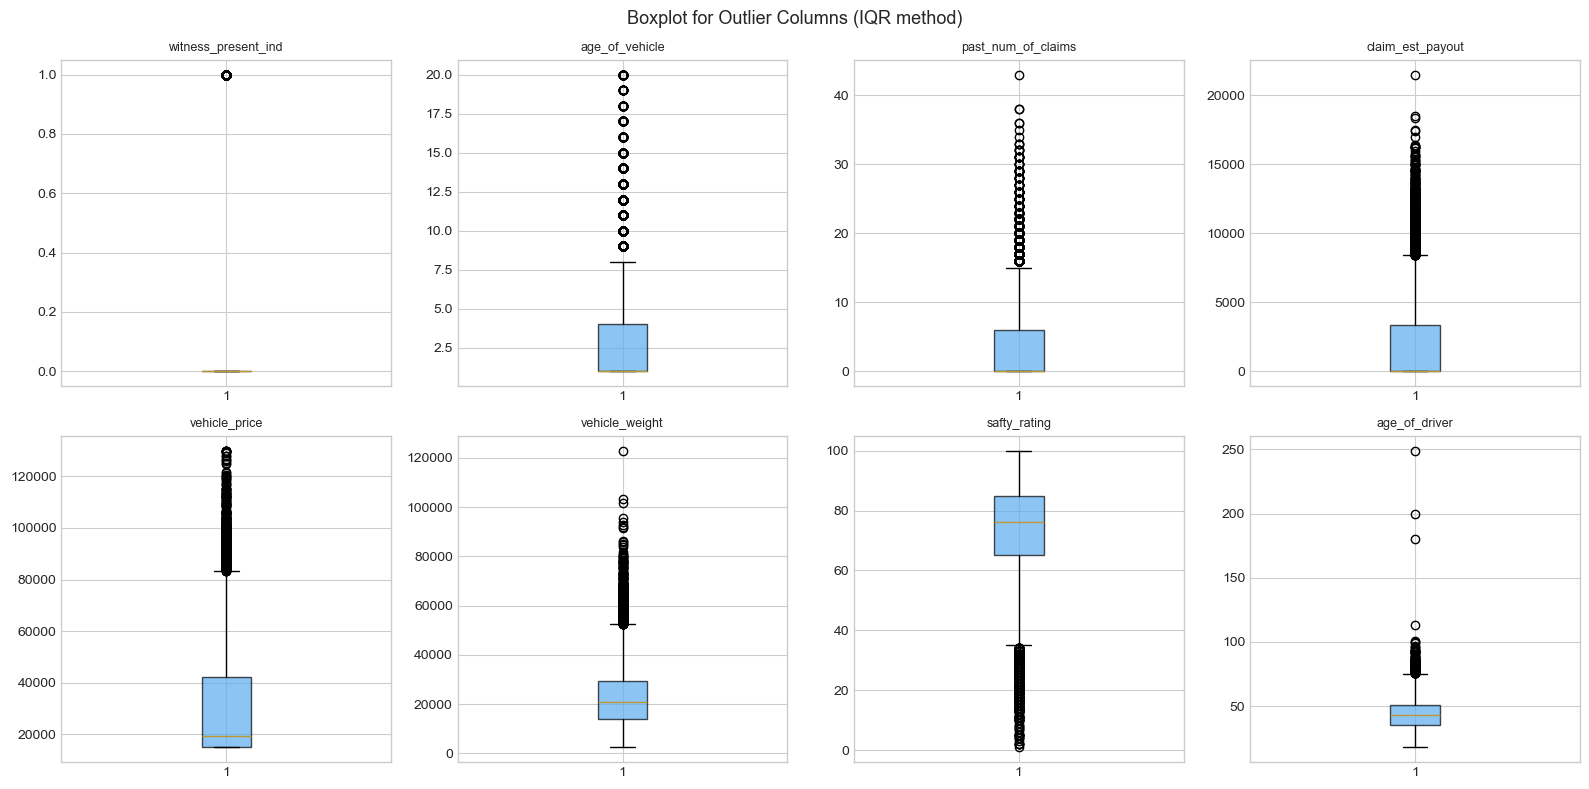

In [14]:
# 5. 이상치 탐지
print("=" * 60)
print("5. 이상치 탐지")
print("=" * 60)

num_cols = train.select_dtypes(include= [np.number]).drop(
    ['claim_number', 'fraud'], axis= 1, errors= 'ignore'
).columns.tolist()

# IQR 기반 이상치 개수 집계
outlier_summary = {}
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_summary[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'Lower': round(lower, 2), 'Upper': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier (%)': round(n_out / len(train) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('Outlier Count', ascending= False)
display(outlier_df)

# 이상치가 있는 변수 시각화
outlier_cols = outlier_df[outlier_df['Outlier Count'] > 0].index.tolist()

if outlier_cols:
    n_cols_vis = min(len(outlier_cols), 8)
    fig, axes = plt.subplots(2, 4, figsize= (16, 8))
    axes = axes.ravel()
    for i, col in enumerate(outlier_cols[:n_cols_vis]):
        axes[i].boxplot(train[col].dropna(), vert= True, patch_artist= True,
                        boxprops=dict(facecolor= '#5cacee', alpha= 0.7))
        axes[i].set_title(f'{col}', fontsize= 9)
        axes[i].set_xlabel('')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplot for Outlier Columns (IQR method)', fontsize= 13)
    plt.tight_layout()
    plt.show()

6. Fraud 비율 심층 분석


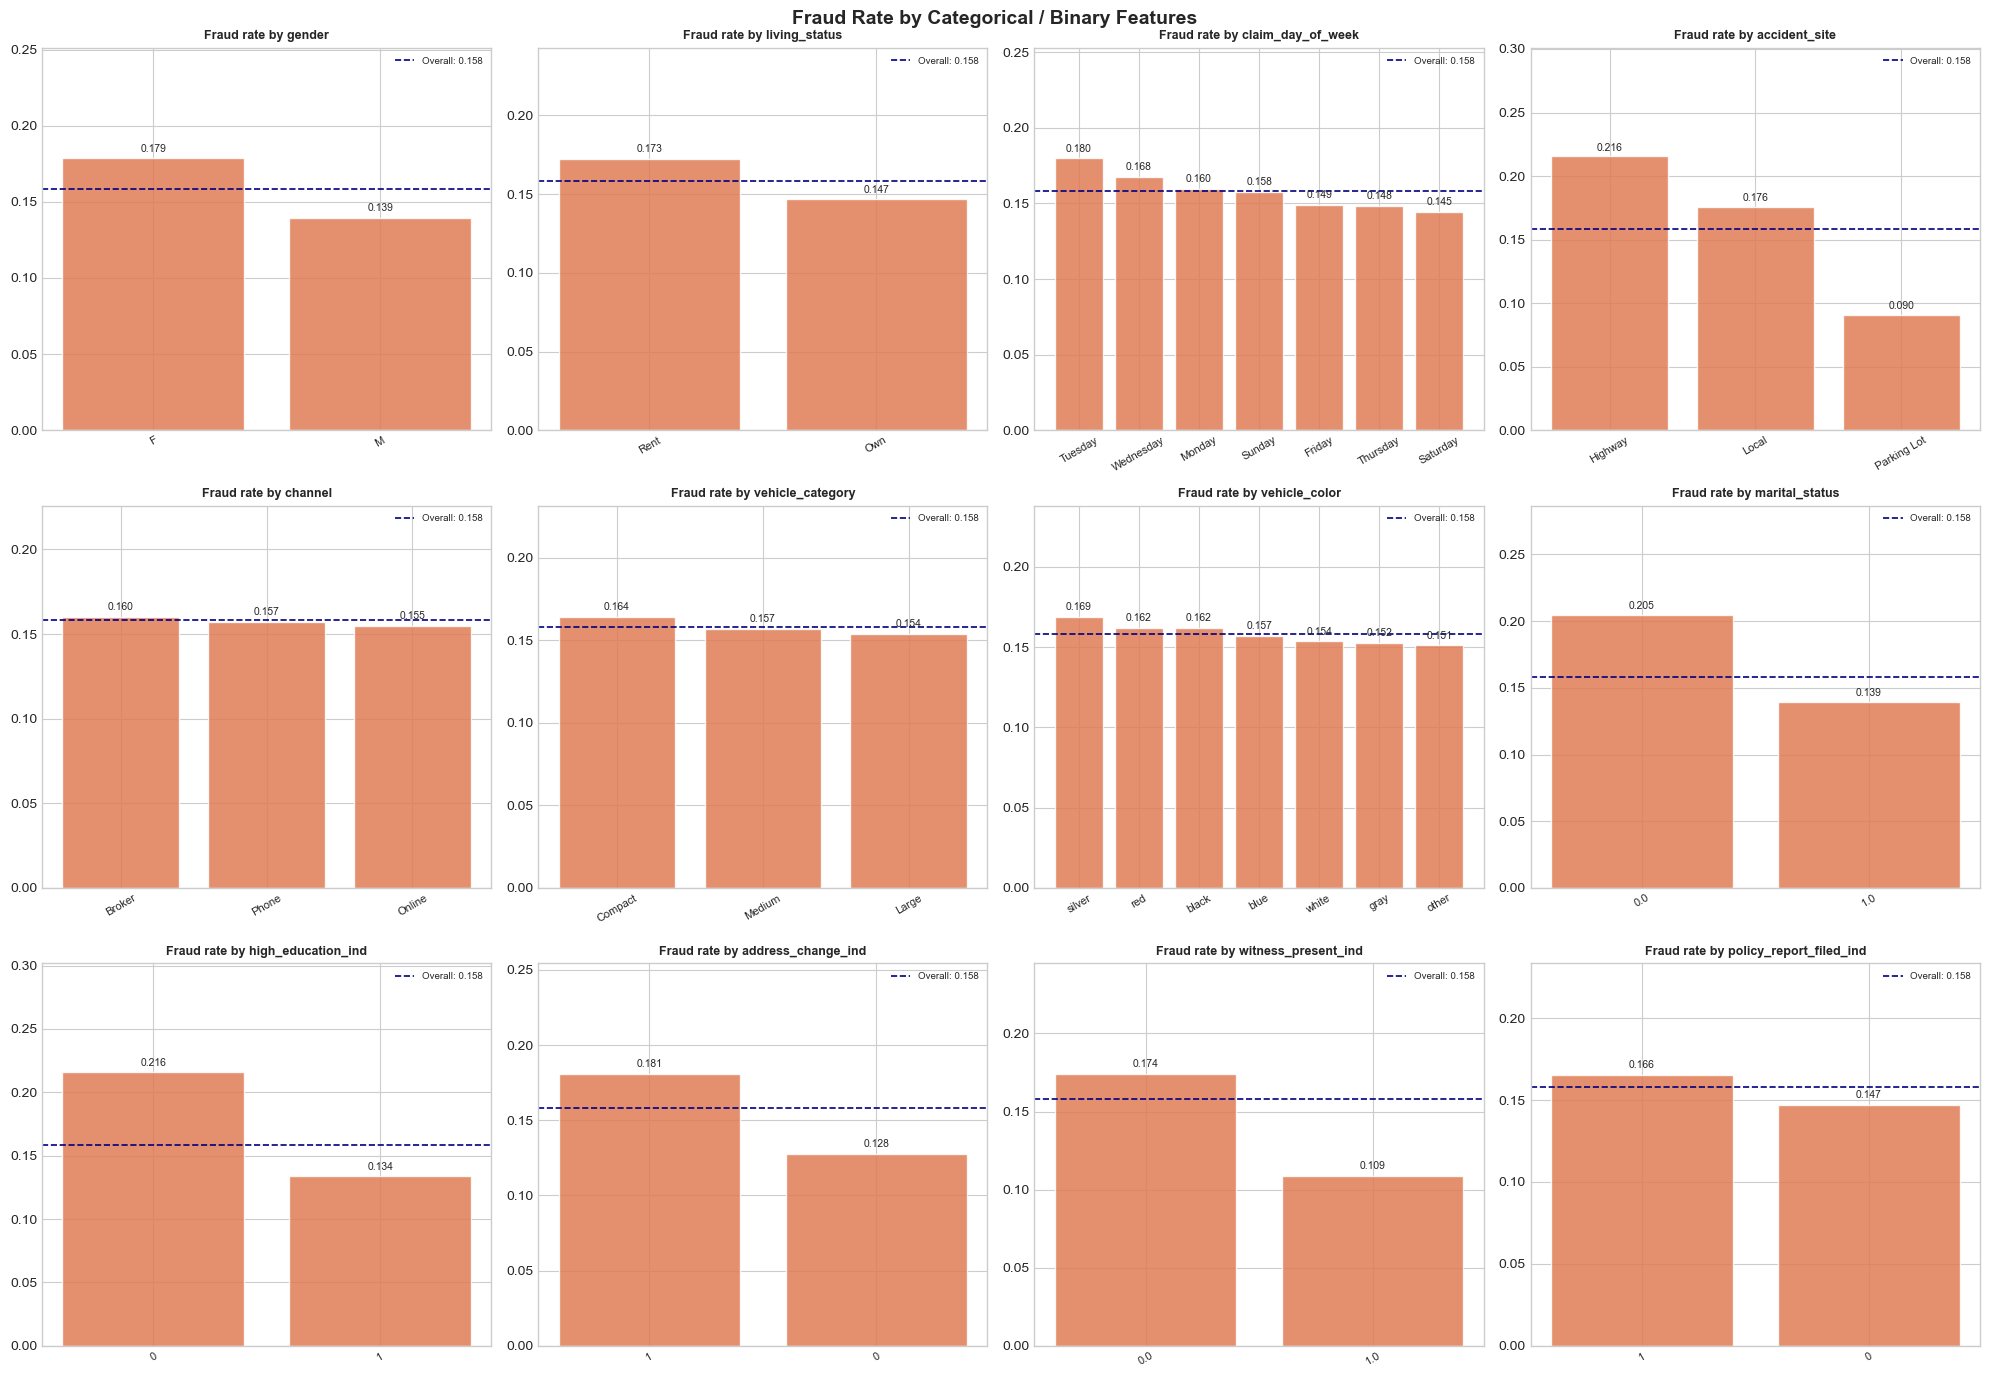

In [16]:
# 6. 사기(Fraud) 비율 심층 분석 - 전체 피처별
print("=" * 60)
print("6. Fraud 비율 심층 분석")
print("=" * 60)

# 6-1. 범주형 변수별 Fraud 비율
cat_features = ['gender', 'living_status', 'claim_day_of_week',
                'accident_site', 'channel', 'vehicle_category',
                'vehicle_color', 'marital_status',
                'high_education_ind', 'address_change_ind',
                'witness_present_ind', 'policy_report_filed_ind']
cat_features = [c for c in cat_features if c in train.columns]

n_r, n_c = 3, 4
fig, axes = plt.subplots(n_r, n_c, figsize= (20, 14))
axes = axes.ravel()

for i, col in enumerate(cat_features):
    fraud_rate = train.groupby(col).fraud.mean().sort_values(ascending= False)
    counts = train[col].value_counts()
    ax = axes[i]
    bars = ax.bar(fraud_rate.index.astype(str), fraud_rate.values,
                  color= '#e07b54', alpha= 0.85, edgecolor= 'white')
    ax.axhline(train.fraud.mean(), color= 'navy', linestyle= '--',
               linewidth= 1.2, label= f'Overall: {train.fraud.mean():.3f}')
    for bar, val in zip(bars, fraud_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha= 'center', va= 'bottom', fontsize= 7.5)
    ax.set_title(f'Fraud rate by {col}', fontsize= 9, fontweight= 'bold')
    ax.set_ylim(0, fraud_rate.max() * 1.35 + 0.01)
    ax.tick_params(axis= 'x', rotation= 30, labelsize= 8)
    ax.legend(fontsize= 7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud Rate by Categorical / Binary Features', fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

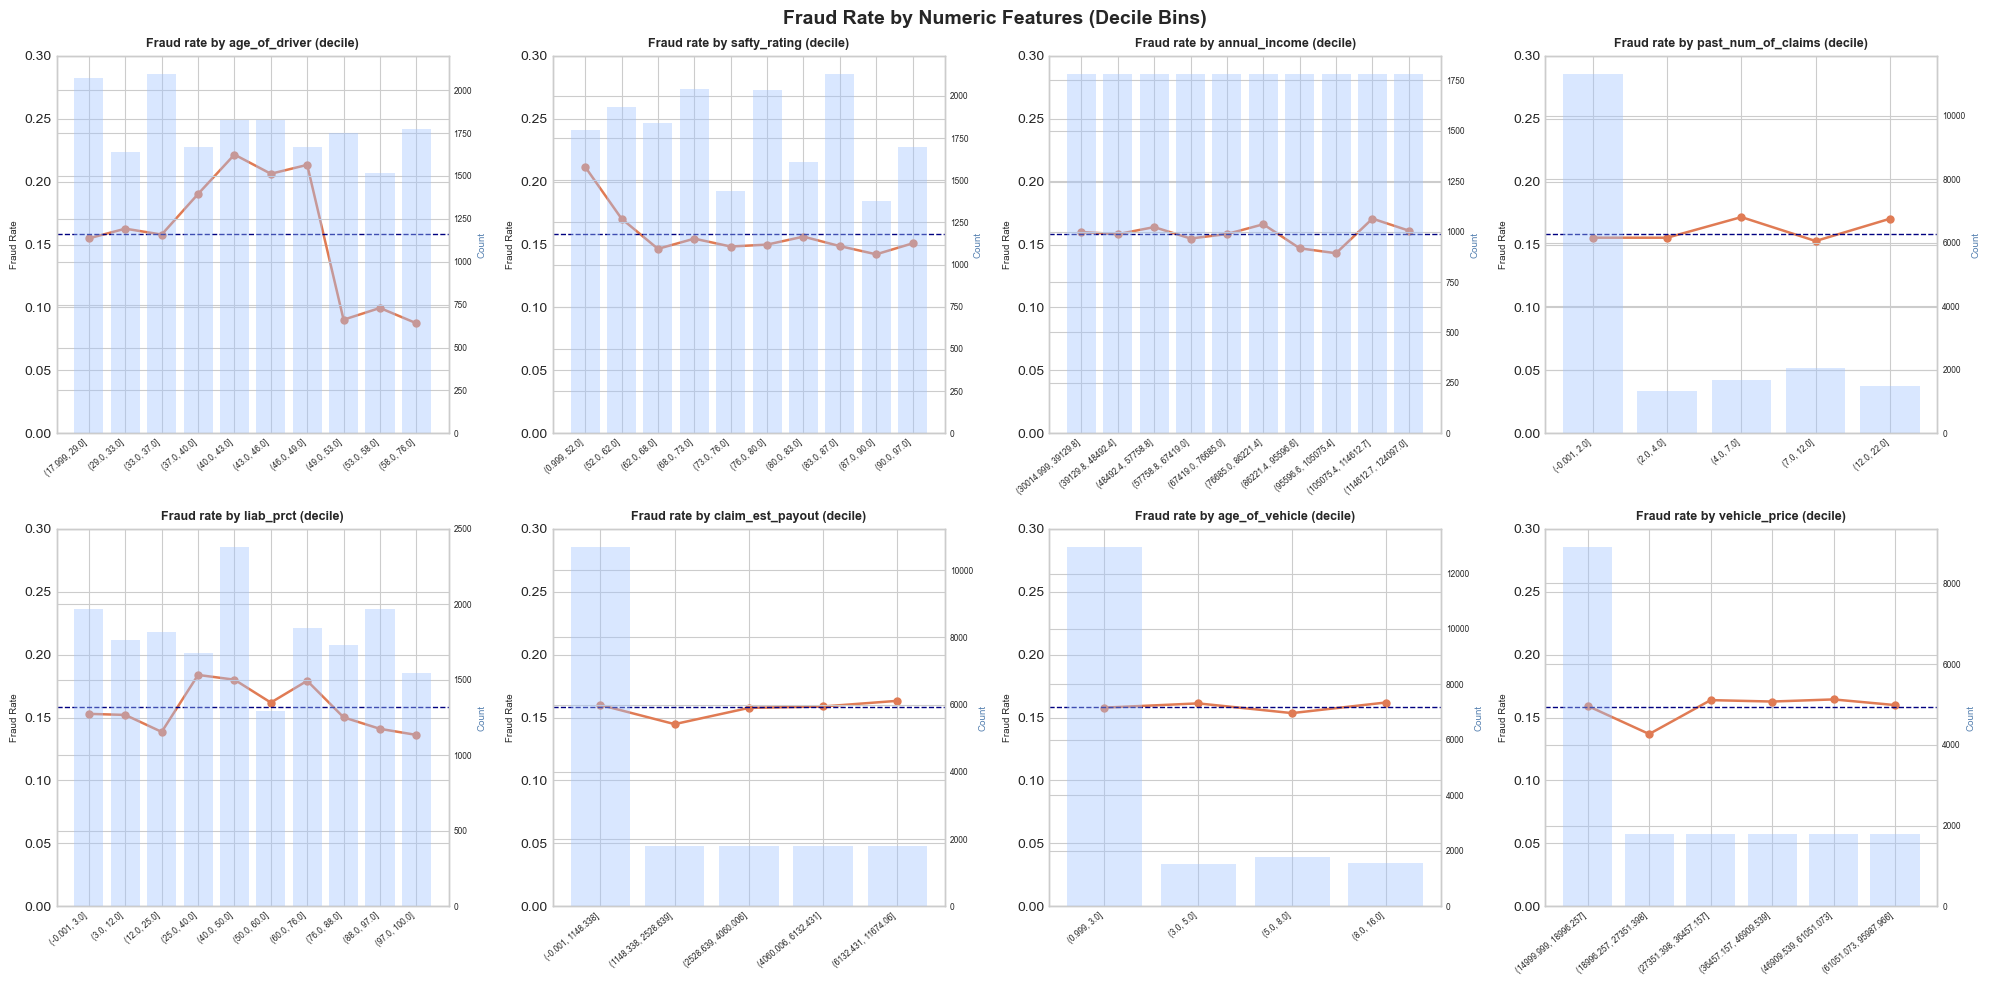

In [17]:
# 6-2. 수치형 변수별 Fraud 비율
num_fraud_cols = ['age_of_driver', 'safty_rating', 'annual_income',
                  'past_num_of_claims', 'liab_prct', 'claim_est_payout',
                  'age_of_vehicle', 'vehicle_price']
num_fraud_cols = [c for c in num_fraud_cols if c in train.columns]

fig, axes = plt.subplots(2, 4, figsize= (20, 10))
axes = axes.ravel()

for i, col in enumerate(num_fraud_cols):
    ax = axes[i]
    # 0 값이 많은 컬럼은 구간을 따로 처리
    clean = train[train[col] <= train[col].quantile(0.99)].copy()
    clean['bin'] = pd.qcut(clean[col], q= 10, duplicates= 'drop')
    rate = clean.groupby('bin', observed= True).fraud.mean()
    cnt = clean.groupby('bin', observed= True).fraud.count()

    ax2 = ax.twinx()
    ax2.bar(range(len(cnt)), cnt.values, color= '#a0c4ff', alpha= 0.4, label= 'Count')
    ax2.set_ylabel('Count', fontsize= 7, color= '#5580b0')
    ax2.tick_params(labelsize= 6)

    ax.plot(range(len(rate)), rate.values, 'o-', color= '#e07b54', linewidth= 1.8, markersize= 5)
    ax.axhline(train.fraud.mean(), color= 'navy', linestyle= '--', linewidth= 1)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(b) for b in rate.index], rotation= 40, ha= 'right', fontsize= 6)
    ax.set_title(f'Fraud rate by {col} (decile)', fontsize= 9, fontweight= 'bold')
    ax.set_ylabel('Fraud Rate', fontsize= 7)
    ax.set_ylim(0, max(rate.max() * 1.3, 0.3))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud Rate by Numeric Features (Decile Bins)', fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

7. 시간 기반 분석
claim_date 범위: 2015-01-01 ~ 2016-12-31
연도 분포:
claim_year
2015    9113
2016    8887
Name: count, dtype: int64


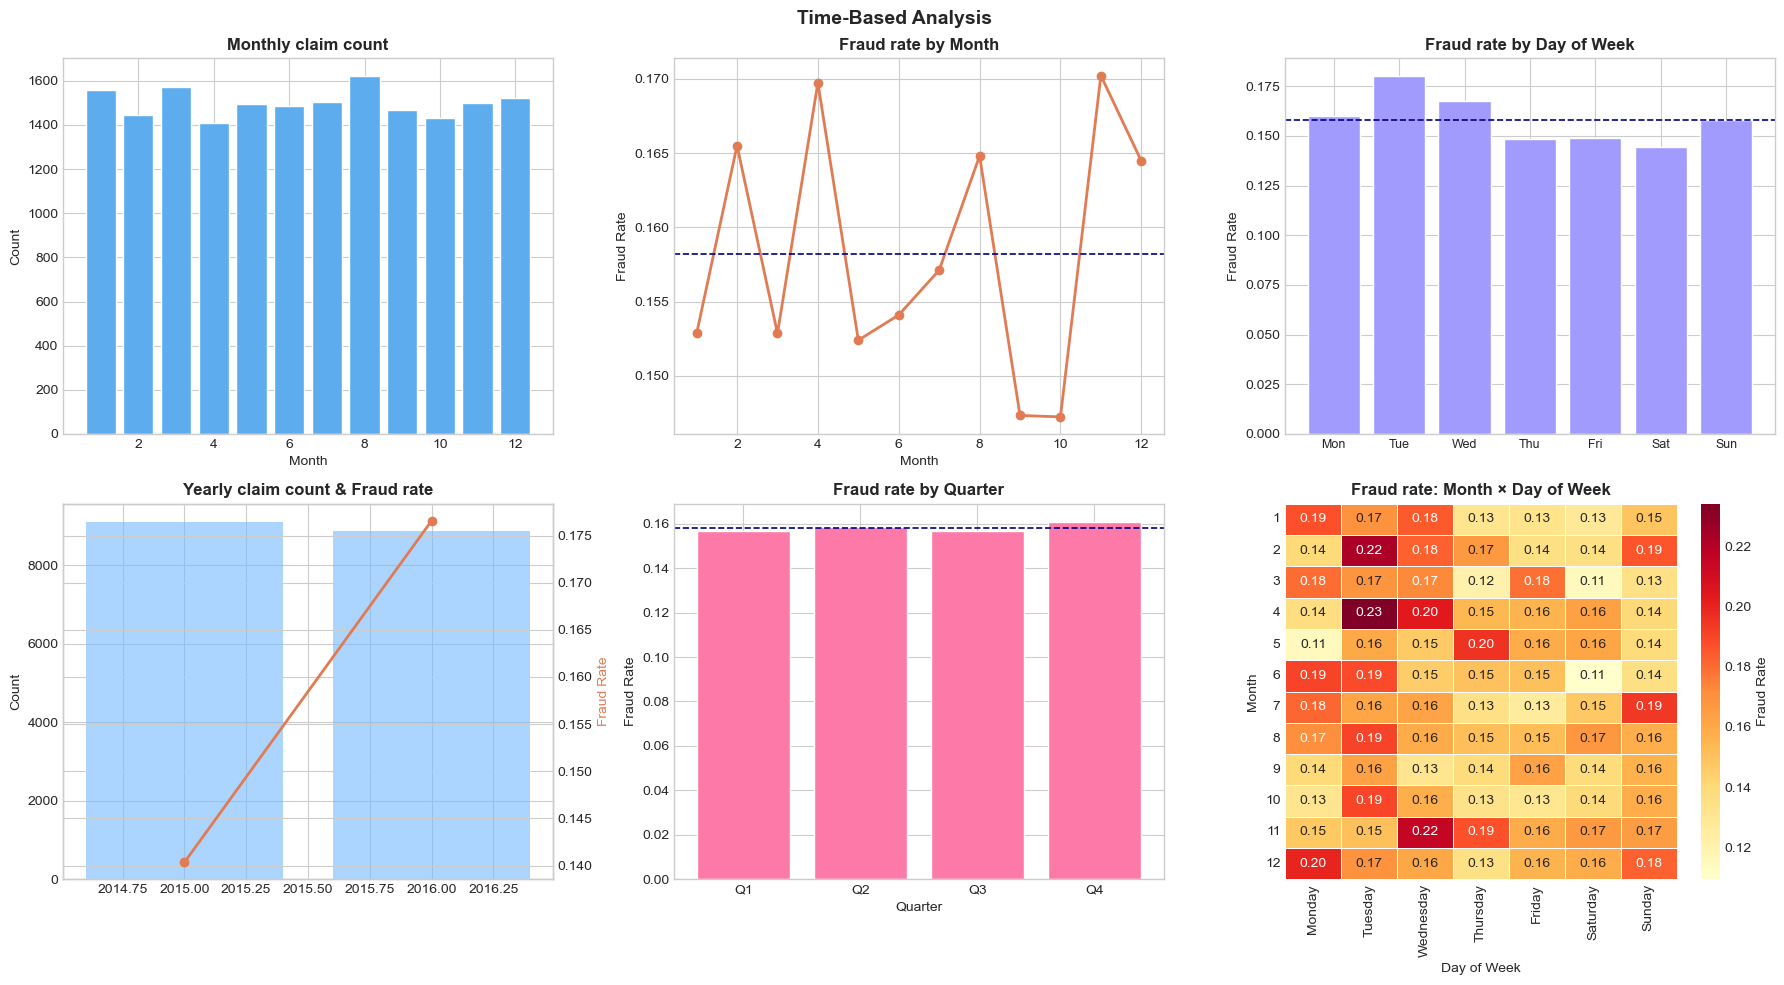

In [19]:
# 7. 시간 기반 분석
print("=" * 60)
print("7. 시간 기반 분석")
print("=" * 60)

train['claim_date_dt'] = pd.to_datetime(train.claim_date, errors= 'coerce')
train['claim_year'] = train.claim_date_dt.dt.year
train['claim_month'] = train.claim_date_dt.dt.month
train['claim_quarter'] = train.claim_date_dt.dt.quarter

print(f"claim_date 범위: {train.claim_date_dt.min().date()} ~ {train.claim_date_dt.max().date()}")
print(f"연도 분포:\n{train.claim_year.value_counts().sort_index()}")

fig, axes = plt.subplots(2, 3, figsize= (18, 10))

# 7-1. 월별 청구 건수
monthly_cnt = train.groupby('claim_month').size()
axes[0, 0].bar(monthly_cnt.index, monthly_cnt.values, color= '#5cacee', edgecolor= 'white')
axes[0, 0].set_title('Monthly claim count', fontweight= 'bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Count')

# 7-2. 월별 Fraud 비율
monthly_fraud = train.groupby('claim_month').fraud.mean()
axes[0, 1].plot(monthly_fraud.index, monthly_fraud.values, 'o-', color= '#e07b54', linewidth= 2)
axes[0, 1].axhline(train.fraud.mean(), color= 'navy', linestyle= '--', linewidth= 1.2)
axes[0, 1].set_title('Fraud rate by Month', fontweight= 'bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Fraud Rate')

# 7-3. 요일별 Fraud 비율
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_fraud = train.groupby('claim_day_of_week').fraud.mean().reindex(dow_order)
axes[0, 2].bar(range(len(dow_order)), dow_fraud.values, color= '#a29bfe', edgecolor= 'white')
axes[0, 2].set_xticks(range(len(dow_order)))
axes[0, 2].set_xticklabels([d[:3] for d in dow_order], fontsize= 9)
axes[0, 2].axhline(train.fraud.mean(), color= 'navy', linestyle= '--', linewidth= 1.2)
axes[0, 2].set_title('Fraud rate by Day of Week', fontweight= 'bold')
axes[0, 2].set_ylabel('Fraud Rate')

# 7-4. 연도별 청구 건수 & Fraud 비율
yearly = train.groupby('claim_year').agg(count= ('fraud', 'size'), fraud_rate= ('fraud', 'mean'))
ax4 = axes[1, 0]
ax4_twin = ax4.twinx()
ax4.bar(yearly.index, yearly['count'], color= '#74b9ff', alpha= 0.6)
ax4_twin.plot(yearly.index, yearly.fraud_rate, 'o-', color= '#e07b54', linewidth= 2)
ax4.set_title('Yearly claim count & Fraud rate', fontweight= 'bold')
ax4.set_ylabel('Count')
ax4_twin.set_ylabel('Fraud Rate', color= '#e07b54')

# 7-5. 분기별 Fraud 비율
qtr_fraud = train.groupby('claim_quarter').fraud.mean()
axes[1, 1].bar(qtr_fraud.index, qtr_fraud.values, color= '#fd79a8', edgecolor= 'white')
axes[1, 1].axhline(train.fraud.mean(), color= 'navy', linestyle= '--', linewidth= 1.2)
axes[1, 1].set_title('Fraud rate by Quarter', fontweight= 'bold')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Fraud Rate')
axes[1, 1].set_xticks([1, 2, 3, 4])
axes[1, 1].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

# 7-6. 월별 x 요일별 Fraud 히트맵
pivot = train.pivot_table(values= 'fraud', index= 'claim_month',
                          columns= 'claim_day_of_week', aggfunc= 'mean')
pivot = pivot.reindex(columns= dow_order)
sns.heatmap(pivot, ax= axes[1, 2], cmap= 'YlOrRd', annot= True,
            fmt= '.2f', linewidths= 0.5, cbar_kws= {'label': 'Fraud Rate'})
axes[1, 2].set_title('Fraud rate: Month × Day of Week', fontweight= 'bold')
axes[1, 2].set_xlabel('Day of Week')
axes[1, 2].set_ylabel('Month')
axes[1, 2].set_yticklabels(axes[1, 2].get_yticklabels(), rotation= 0)

plt.suptitle('Time-Based Analysis', fontsize= 14, fontweight= 'bold')
plt.tight_layout()
plt.show()

8. 이진 변수 조합 분석 & 복합 피처 패턴


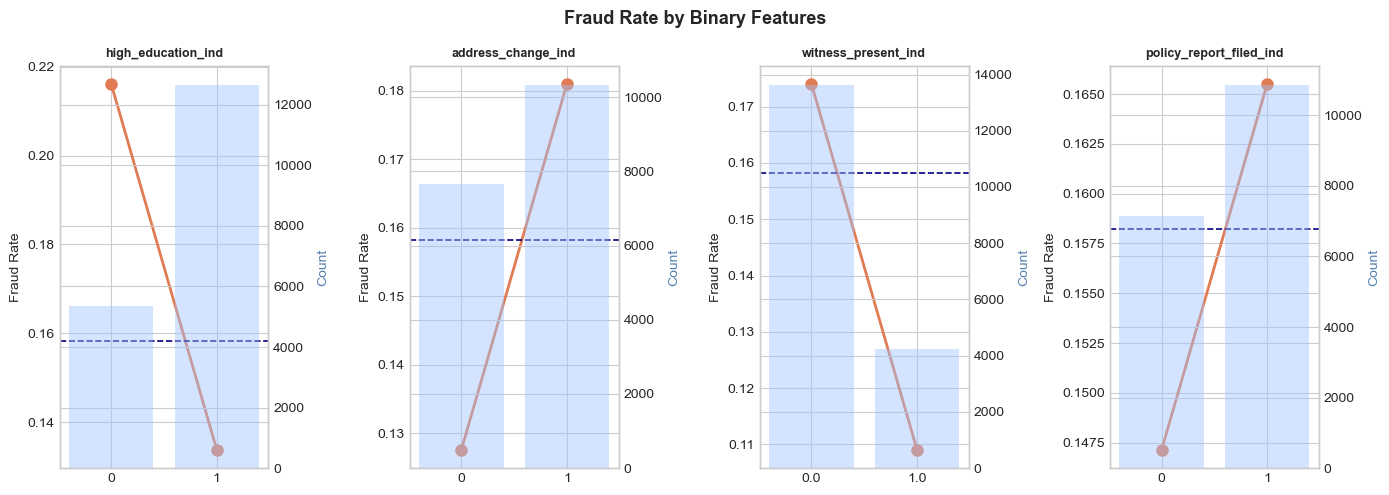


[liab_prct 구간 × accident_site × Fraud 비율]


accident_site,Highway,Local,Parking Lot
liab_bin,,,
0-25,0.206,0.166,0.080
26-50,0.227,0.209,0.104
51-75,0.254,0.173,0.113
76-100,0.195,0.163,0.079


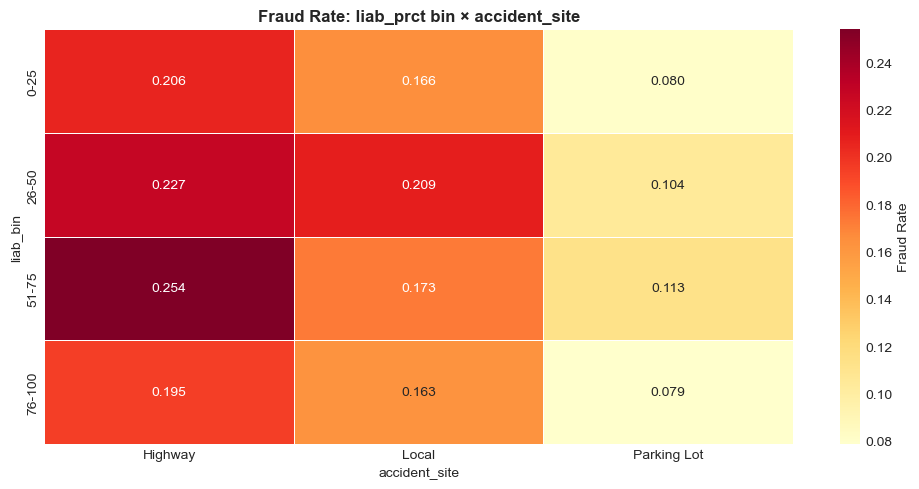

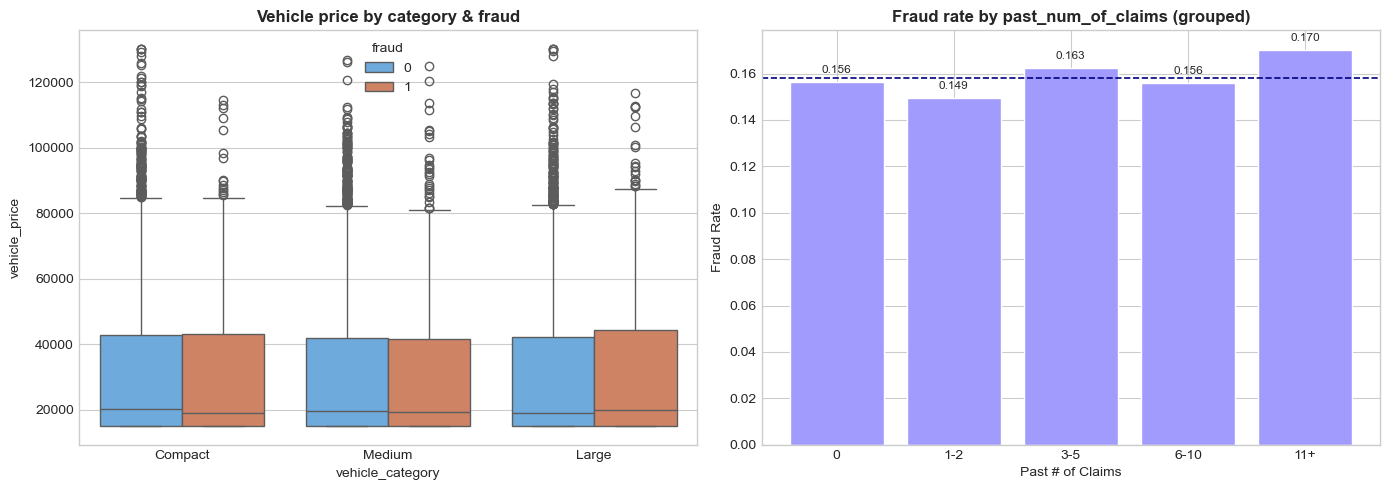


[age_of_driver 분포: 이상치 제거 전/후 비교]
  전체: 18000  /  100세 이하: 17995


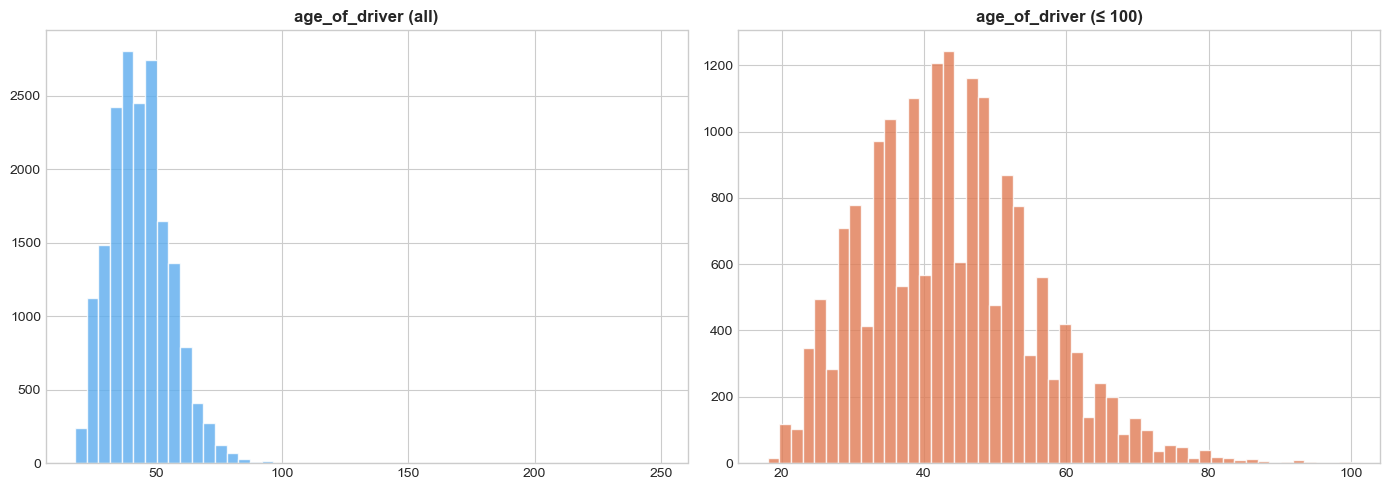


[연령대별 Fraud 비율]
age_group
18-25    0.1523
26-35    0.1585
36-45    0.1980
46-55    0.1499
56-65    0.0974
66+      0.0728
Name: fraud, dtype: float64


In [20]:
# 8. 이진 변수 조합 분석 & 복합 피처 분석
print("=" * 60)
print("8. 이진 변수 조합 분석 & 복합 피처 패턴")
print("=" * 60)

binary_cols = ['high_education_ind', 'address_change_ind',
               'witness_present_ind', 'policy_report_filed_ind']
binary_cols = [c for c in binary_cols if c in train.columns]

# 8-1. 이진 변수들의 Fraud 비율 비교
fraud_rates = {}
for col in binary_cols:
    rate = train.groupby(col)['fraud'].mean()
    fraud_rates[col] = rate

fig, axes = plt.subplots(1, len(binary_cols), figsize= (14, 5))
for i, col in enumerate(binary_cols):
    rate = train.groupby(col)['fraud'].mean()
    cnt = train[col].value_counts().sort_index()
    ax = axes[i]
    ax2 = ax.twinx()
    ax2.bar(cnt.index.astype(str), cnt.values, color= '#a0c4ff', alpha= 0.45, label= 'Count')
    ax.plot(range(len(rate)), rate.values, 'o-', color= '#e07b54', linewidth= 2, markersize= 8)
    ax.axhline(train['fraud'].mean(), color= 'navy', linestyle= '--', linewidth= 1.2)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index.astype(str))
    ax.set_title(col, fontsize= 9, fontweight= 'bold')
    ax.set_ylabel('Fraud Rate')
    ax2.set_ylabel('Count', color= '#5580b0')

plt.suptitle('Fraud Rate by Binary Features', fontsize= 13, fontweight= 'bold')
plt.tight_layout()
plt.show()

# 8-2. 복합 피처 분석: liab_prct × accident_site
print("\n[liab_prct 구간 × accident_site × Fraud 비율]")
train['liab_bin'] = pd.cut(train['liab_prct'], bins= [0, 25, 50, 75, 100],
                           labels= ['0-25', '26-50', '51-75', '76-100'], include_lowest= True)
pivot_liab_site = train.pivot_table(values= 'fraud', index= 'liab_bin',
                                    columns= 'accident_site', aggfunc= 'mean', observed= False)
display(pivot_liab_site.round(3))

fig, ax = plt.subplots(figsize= (10, 5))
sns.heatmap(pivot_liab_site, annot= True, fmt= '.3f', cmap= 'YlOrRd',
            linewidths= 0.5, ax= ax, cbar_kws= {'label': 'Fraud Rate'})
ax.set_title('Fraud Rate: liab_prct bin × accident_site', fontweight= 'bold')
plt.tight_layout()
plt.show()
train.drop(columns= ['liab_bin'], inplace= True)

# 8-3. vehicle_price × vehicle_category 분포
fig, axes = plt.subplots(1, 2, figsize= (14, 5))
sns.boxplot(data= train, x= 'vehicle_category', y= 'vehicle_price',
            hue= 'fraud', palette= {0: '#5cacee', 1: '#e07b54'},
            order= ['Compact', 'Medium', 'Large'], ax= axes[0])
axes[0].set_title('Vehicle price by category & fraud', fontweight= 'bold')

# 8-4. past_num_of_claims 분포 × Fraud
train['claims_bin'] = pd.cut(train['past_num_of_claims'],
                              bins= [-1, 0, 2, 5, 10, 100],
                              labels= ['0', '1-2', '3-5', '6-10', '11+'])
fraud_by_claims = train.groupby('claims_bin', observed= True)['fraud'].mean()
axes[1].bar(fraud_by_claims.index.astype(str), fraud_by_claims.values,
            color= '#a29bfe', edgecolor= 'white')
axes[1].axhline(train['fraud'].mean(), color= 'navy', linestyle= '--', linewidth= 1.2)
axes[1].set_title('Fraud rate by past_num_of_claims (grouped)', fontweight= 'bold')
axes[1].set_xlabel('Past # of Claims')
axes[1].set_ylabel('Fraud Rate')
for bar, val in zip(axes[1].patches, fraud_by_claims.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha= 'center', va= 'bottom', fontsize= 8.5)
plt.tight_layout()
plt.show()
train.drop(columns= ['claims_bin'], inplace= True)

# 8-5. age_of_driver (이상치 제거 후) × Fraud
print("\n[age_of_driver 분포: 이상치 제거 전/후 비교]")
normal_age = train[train['age_of_driver'] <= 100]
print(f"  전체: {len(train)}  /  100세 이하: {len(normal_age)}")
fig, axes = plt.subplots(1, 2, figsize= (14, 5))
axes[0].hist(train['age_of_driver'], bins= 50, color= '#5cacee', edgecolor= 'white', alpha= 0.8)
axes[0].set_title('age_of_driver (all)', fontweight= 'bold')
axes[1].hist(normal_age['age_of_driver'], bins= 50, color= '#e07b54', edgecolor= 'white', alpha= 0.8)
axes[1].set_title('age_of_driver (≤ 100)', fontweight= 'bold')
plt.tight_layout()
plt.show()

age_bins = pd.cut(normal_age['age_of_driver'],
                  bins= [17, 25, 35, 45, 55, 65, 100],
                  labels= ['18-25', '26-35', '36-45', '46-55', '56-65', '66+'])
print("\n[연령대별 Fraud 비율]")
print(normal_age.assign(age_group=age_bins)
      .groupby('age_group', observed=True)['fraud'].mean().round(4))

---
## 9. EDA 종합 인사이트 & 피처 엔지니어링 계획

---

### 주요 인사이트 요약

#### 1) 타깃 변수 (fraud)
- 클래스 불균형 존재 → **SMOTE / class_weight 등 불균형 처리 필요**
- `claim_est_payout = 0` 인 케이스에서 Fraud 비율이 유독 높음 → 보험금 미지급 상태에서 사기 청구 패턴

#### 2) 이상치
- `age_of_driver` 최댓값 249 → **명백한 데이터 오류** (100세 초과 → cap 처리 또는 제거)
- `past_num_of_claims` 극단값(18+) → 로그 변환 고려

#### 3) 수치형 변수 패턴
- `safty_rating` 이 낮을수록 Fraud 비율 높음 (안전 불량 → 사기 위험)
- `liab_prct` 100% 구간에서 Fraud 집중 (책임 비율 100% = 전적 과실)
- `annual_income` 낮은 구간에서 Fraud 비율 약간 상승

#### 4) 범주형 변수 패턴
- `accident_site: Highway` 에서 Fraud 비율 높음
- `channel: Online` 에서 Fraud 비율 높음 (대면 없이 청구)
- `witness_present_ind = 0` (목격자 없음) → Fraud 비율 높음
- `policy_report_filed_ind = 0` (경찰 신고 안함) → Fraud 비율 높음
- `address_change_ind = 1` (주소 변경) → Fraud 비율 높음

#### 5) 시간 기반 패턴
- 특정 월/요일에 Fraud 집중 가능 → 시간 피처 활용 가치 있음

---

### 피처 엔지니어링 계획

| 새 피처 | 생성 방법 | 기대 효과 |
|---|---|---|
| `age_driver_capped` | `age_of_driver.clip(upper=100)` | 이상치 제거 |
| `payout_is_zero` | `(claim_est_payout == 0).astype(int)` | 보험금 미지급 패턴 포착 |
| `log_payout` | `log1p(claim_est_payout)` | 우측 편향 완화 |
| `log_vehicle_price` | `log1p(vehicle_price)` | 우측 편향 완화 |
| `income_per_vehicle` | `annual_income / vehicle_price` | 상대적 부 수준 |
| `liab_full` | `(liab_prct == 100).astype(int)` | 전적 과실 여부 |
| `no_witness_no_report` | `(witness=0) & (policy_report=0)` | 고위험 조합 |
| `claim_month` | `pd.to_datetime(claim_date).dt.month` | 계절성 |
| `claim_day_num` | 요일 → 숫자 인코딩 | 모델 입력 |
| `vehicle_age_group` | `age_of_vehicle` 구간화 | 비선형 관계 |
| `age_group` | `age_of_driver` 구간화 (이상치 제거 후) | 비선형 관계 |
| `zip_region` | `zip_code // 1000` | 지역 단위 집계 |

---

### 데이터 품질 이슈

- `marital_status`: 결측값 2건 → dropna
- `witness_present_ind`: 결측값 존재 → 0으로 대체 (목격자 없음으로 간주) + 별도 결측 플래그
- `age_of_driver > 100`: 명백한 오입력 → 제거
- `vehicle_price = 15000.0`: 최솟값에 다수 집중 → 하한값(floor) 가능성, 원인 확인 필요